In [1]:
import os

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### IMPORT THE CSV DATA AS PANDAS DATAFRAME


In [3]:
df = pd.read_csv("data/StudentsPerformance.csv")

In [4]:
df.sample(5, random_state = 42)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
521,female,group C,associate's degree,standard,none,91,86,84
737,female,group B,some college,free/reduced,completed,53,66,73
740,male,group D,bachelor's degree,standard,none,80,73,72
660,male,group C,some college,free/reduced,none,74,77,73
411,male,group E,some college,standard,completed,84,83,78


In [5]:
df.shape

(1000, 8)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [8]:
df.describe()


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [12]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [13]:
print("Gender Categories: ", end=" ")
print(df['gender'].unique())

print("Race/Ethnicity Categories: ", end=" ")
print(df['race/ethnicity'].unique())

print("Parental Level of Education Categories: ", end=" ")
print(df['parental level of education'].unique())

print("Lunch Categories: ", end=" ")
print(df['lunch'].unique())

print("Test Preparation Course Categories: ", end=" ")
print(df['test preparation course'].unique())

print("Math Score Categories: ", end=" ")
print(df['math score'].unique())

print("Reading Score Categories: ", end=" ")
print(df['reading score'].unique())

print("Writing Score Categories: ", end=" ")
print(df['writing score'].unique())

Gender Categories:  <StringArray>
['female', 'male']
Length: 2, dtype: str
Race/Ethnicity Categories:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Parental Level of Education Categories:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Lunch Categories:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Test Preparation Course Categories:  <StringArray>
['none', 'completed']
Length: 2, dtype: str
Math Score Categories:  [ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]
Reading Score Categories:  [ 72  90  95  57  78  83  43  64  

In [17]:
# defining the categorical and numerical features in the dataset
numeric_features = df.select_dtypes(exclude='object').columns.tolist()

categorical_features = df.select_dtypes(include='object').columns.tolist()

print(f"There are {len(numeric_features)} numeric features")
print(f"There are {len(categorical_features)} categorical features")

print(f"The numeric features are:\n{numeric_features}")

print(f"The categorical features are:\n{categorical_features}")

There are 3 numeric features
There are 5 categorical features
The numeric features are:
['math score', 'reading score', 'writing score']
The categorical features are:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [18]:
# creating a total score and avg score
df["total_score"] = df['math score'] + df['reading score'] + df["writing score"]
df['average'] = df['total_score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [20]:
reading_full = df[df['reading score'] == 100]['average'].count()
writing_full = df[df["writing score"] == 100]['average'].count()
math_full = df[df['math score'] == 100]['average'].count()

print(f"number of student with full marks in maths : {math_full}")
print(f"number of studnet with full marks in reading: {reading_full}")
print(f"number of student with full marks in writing: {writing_full}")

number of student with full marks in maths : 7
number of studnet with full marks in reading: 17
number of student with full marks in writing: 14


In [22]:
reading_less_20 = df[df['reading score'] <= 20]['average'].count()
writing_less_20 = df[df['writing score'] <= 20]['average'].count()
maths_less_20 = df[df['math score'] <= 20]['average'].count()

print(f"number of student with score less than 20 in maths: {maths_less_20}")
print(f"number of student with score less than 20 in reading: {reading_less_20}")
print(f"number of student with score less than 20 in writing: {writing_less_20}")

number of student with score less than 20 in maths: 4
number of student with score less than 20 in reading: 1
number of student with score less than 20 in writing: 3


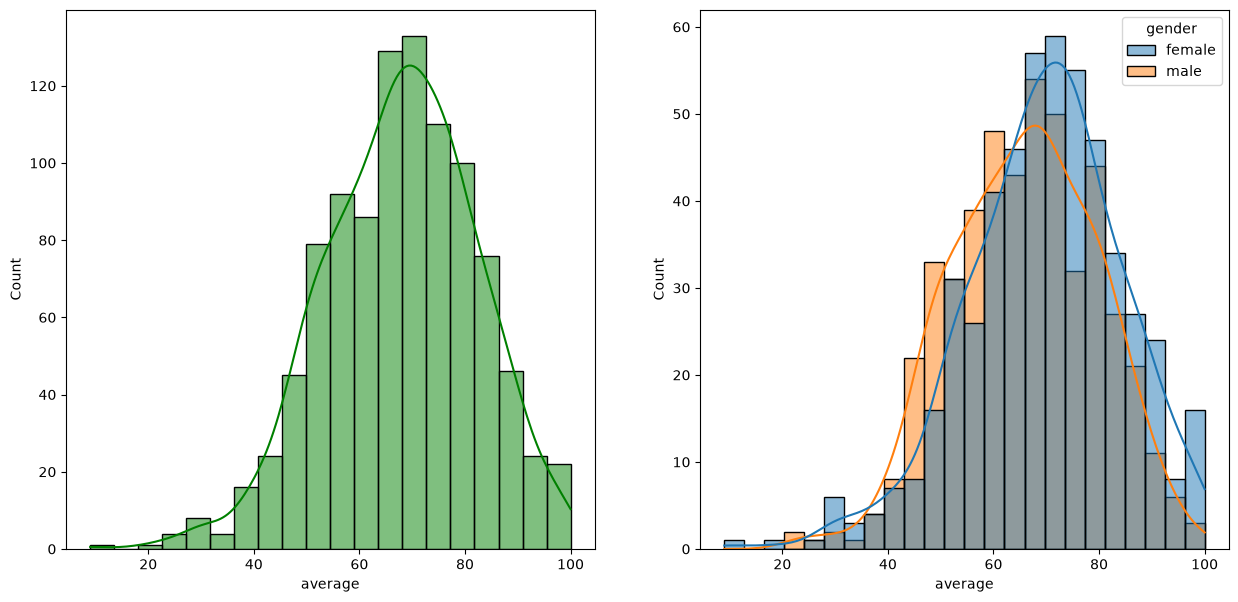

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

sns.histplot(
    data=df,
    x='average',
    bins=20,
    kde=True,
    color='g',
    ax=axs[0]
)

sns.histplot(
    data=df,
    x='average',
    kde=True,
    hue='gender',
    ax=axs[1]
)

plt.show()

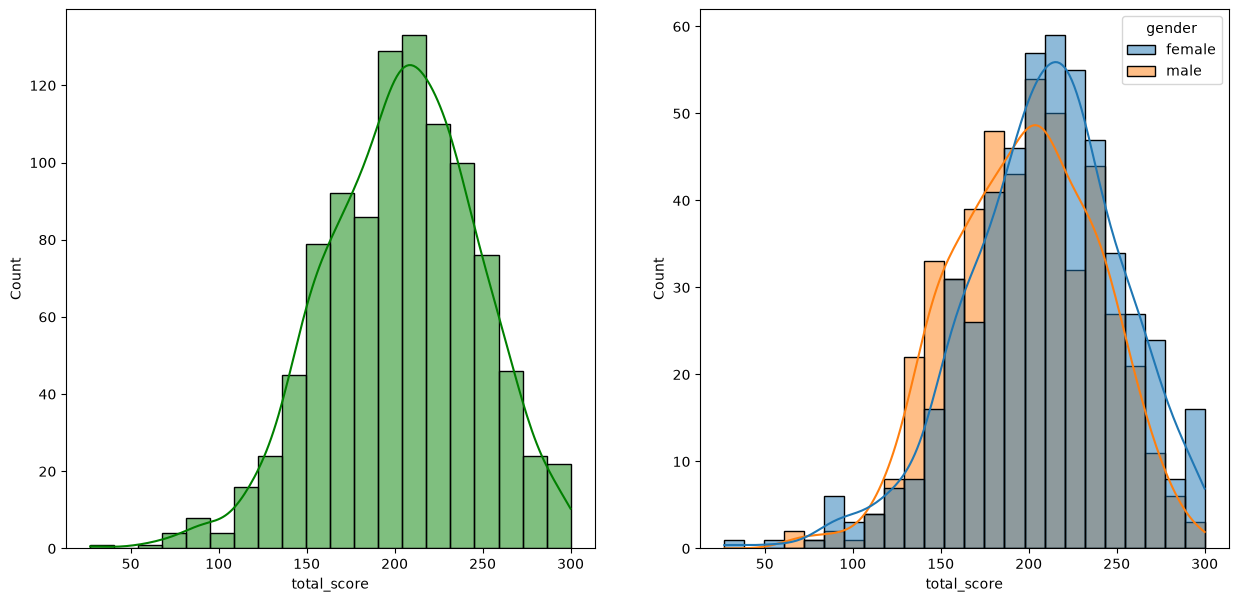

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

sns.histplot(
    data=df,
    x='total_score',
    bins=20,
    kde=True,
    color='g',
    ax=axs[0]
)

sns.histplot(
    data=df,
    x='total_score',
    kde=True,
    hue='gender',
    ax=axs[1]
)
plt.show()

### female students performs better

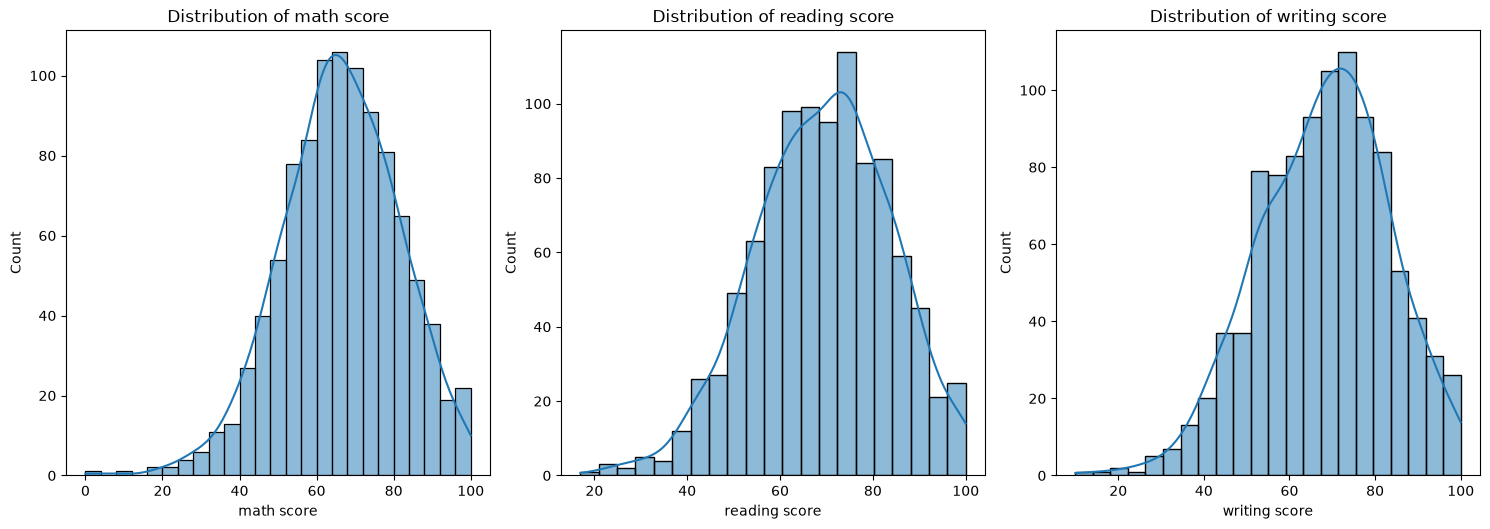

In [35]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

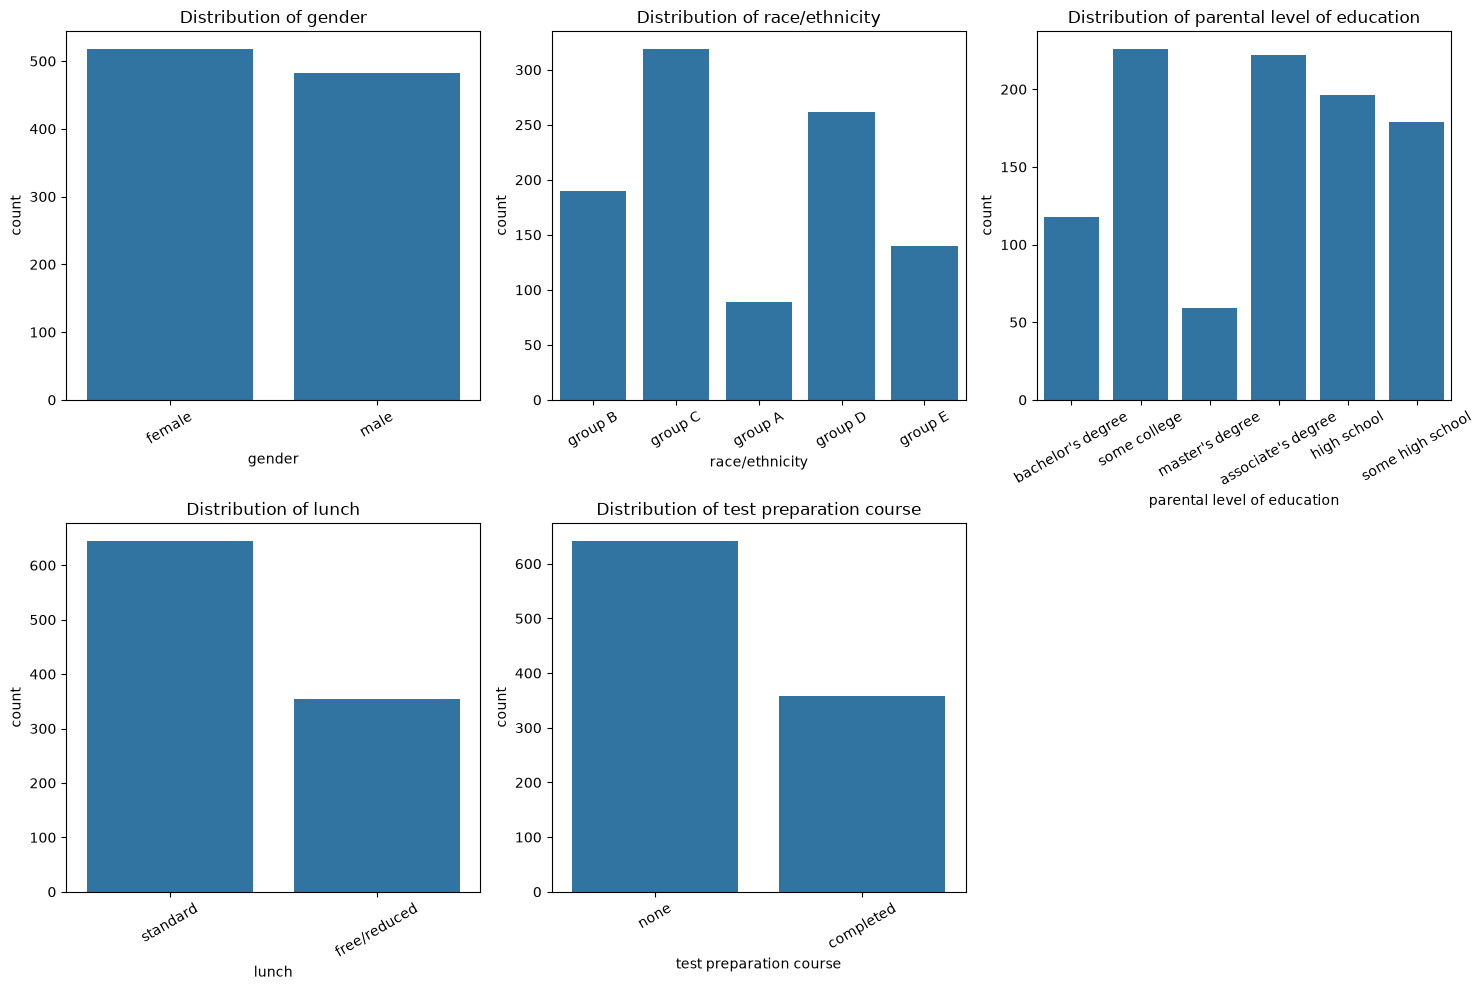

In [37]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

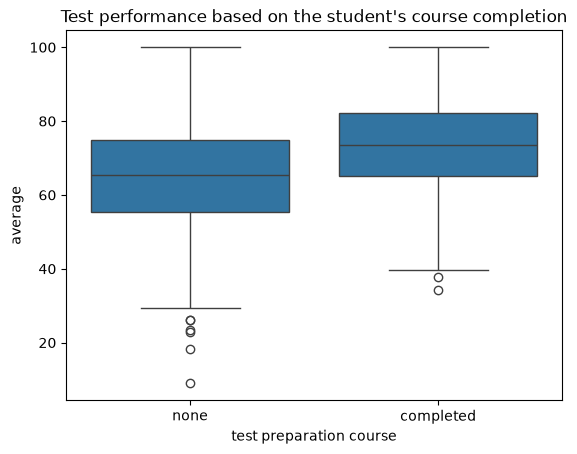

In [40]:
sns.boxplot(
    data = df,
    x = "test preparation course",
    y = "average"
)

plt.title("Test performance based on the student's course completion")
plt.show()

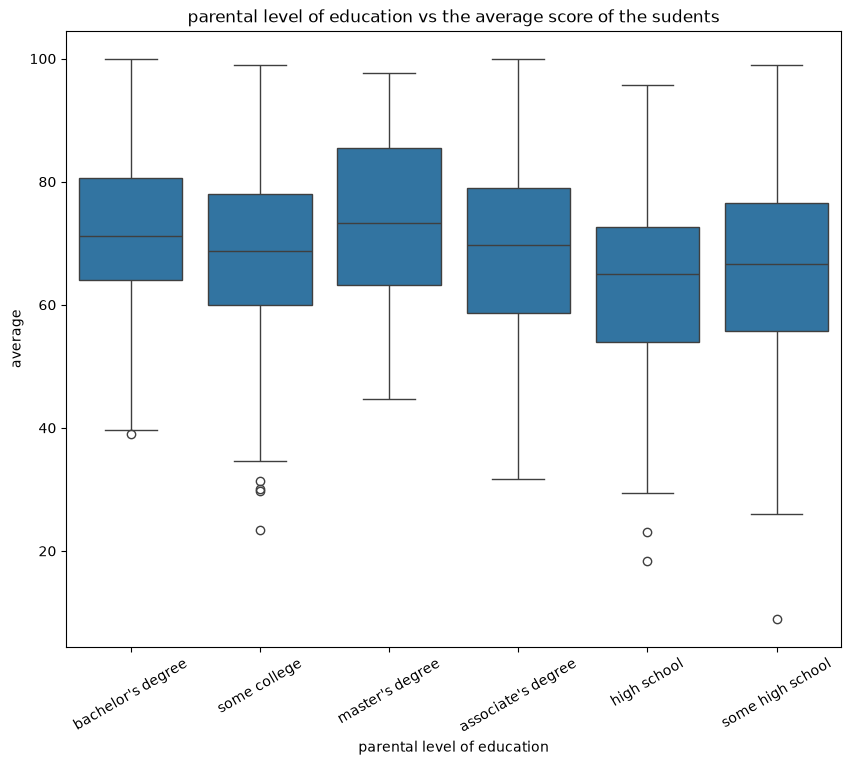

In [43]:
plt.figure(figsize = (10,8))

sns.boxplot(
    data = df,
    x = "parental level of education",
    y = "average"
)

plt.xticks(rotation =30)
plt.title("parental level of education vs the average score of the sudents")
plt.show()

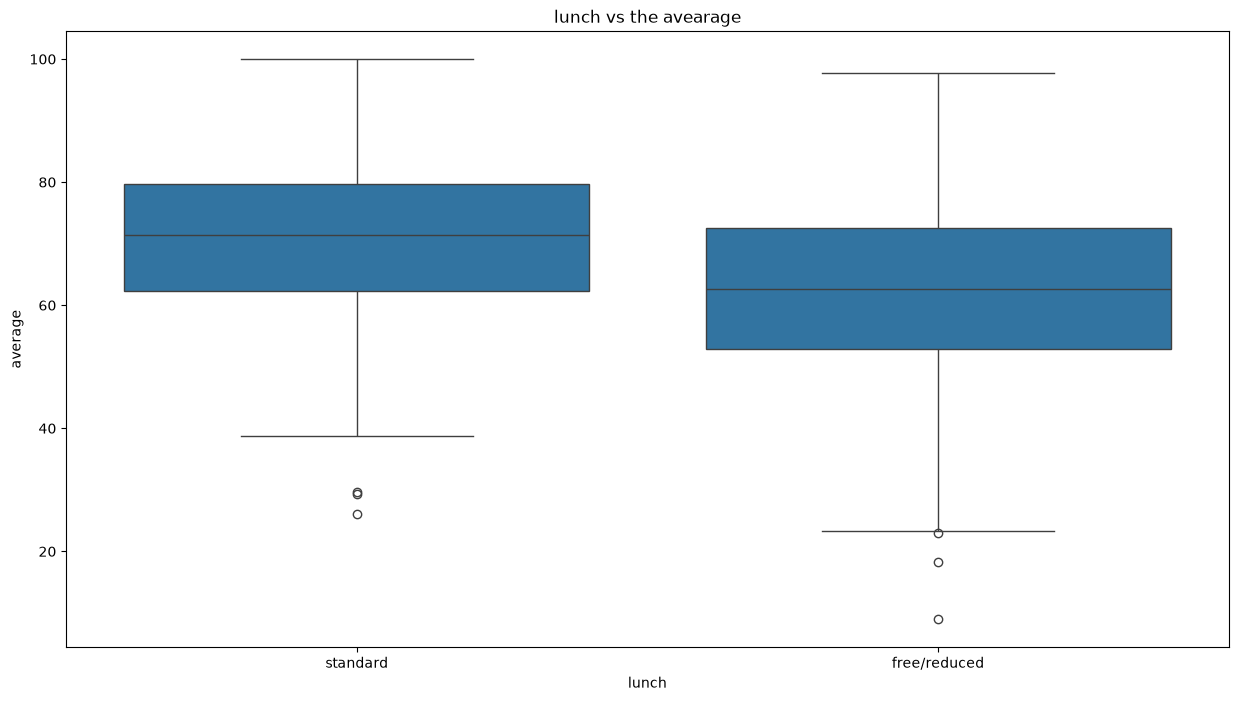

In [44]:
plt.figure(figsize = (15,8))

sns.boxplot(
    data =df,
    x = "lunch",
    y = 'average'
)

plt.title("lunch vs the avearage")
plt.show()

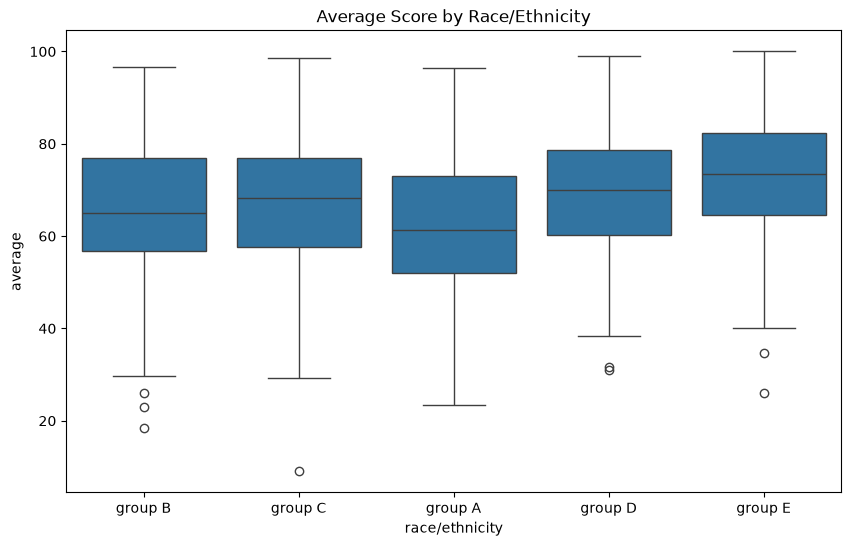

In [45]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='race/ethnicity',
    y='average'
)

plt.title("Average Score by Race/Ethnicity")

plt.show()

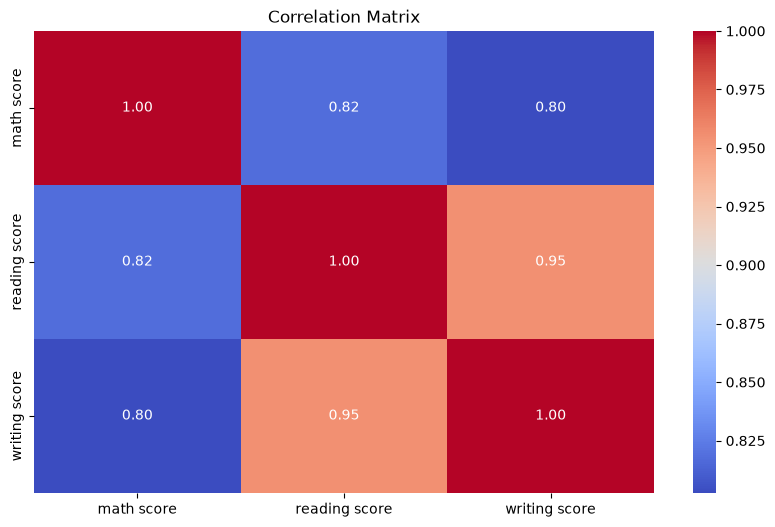

In [46]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df[numeric_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

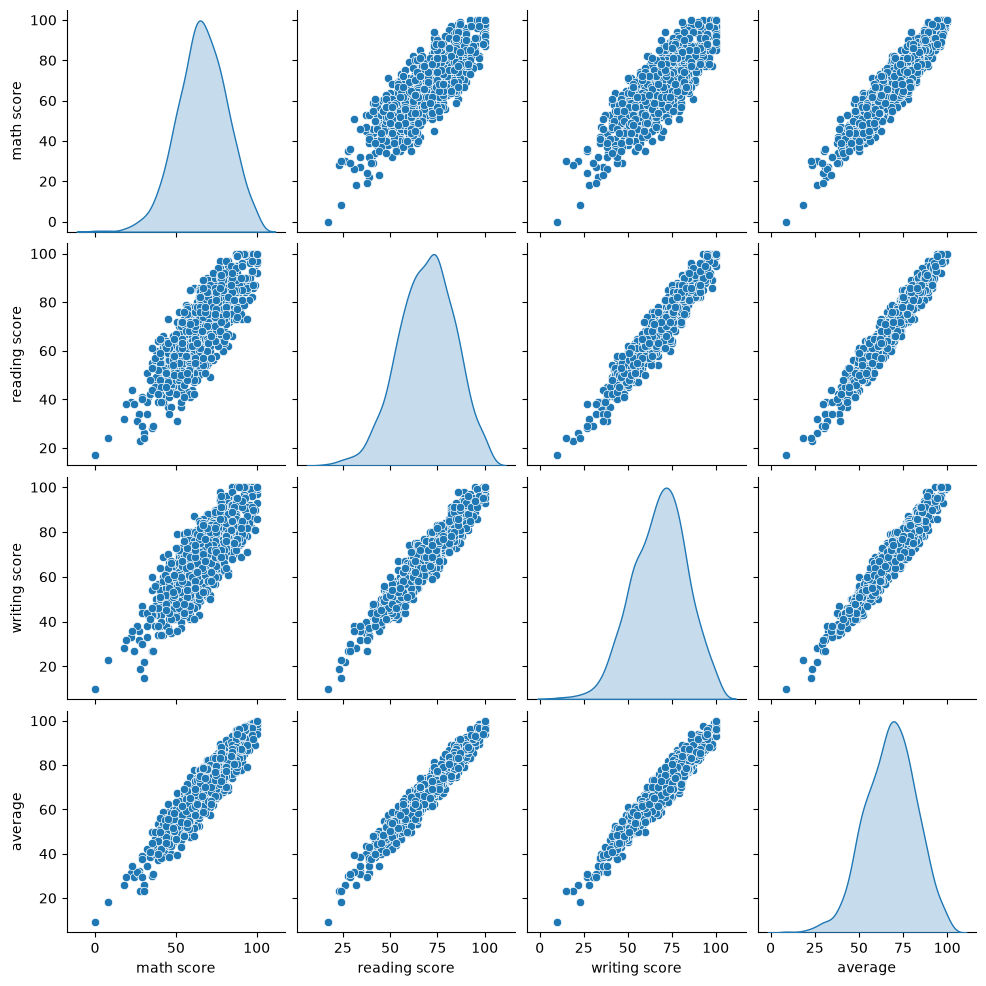

In [47]:
sns.pairplot(
    df[['math score', 'reading score', 'writing score', 'average']],
    diag_kind='kde'
)

plt.show()

In [48]:
df.groupby('test preparation course')['average'].mean()

test preparation course
completed    72.669460
none         65.038941
Name: average, dtype: float64

In [50]:
df['pass'] = (df['average'] >= 40).astype(int)
df['pass']

0      1
1      1
2      1
3      1
4      1
      ..
995    1
996    1
997    1
998    1
999    1
Name: pass, Length: 1000, dtype: int64

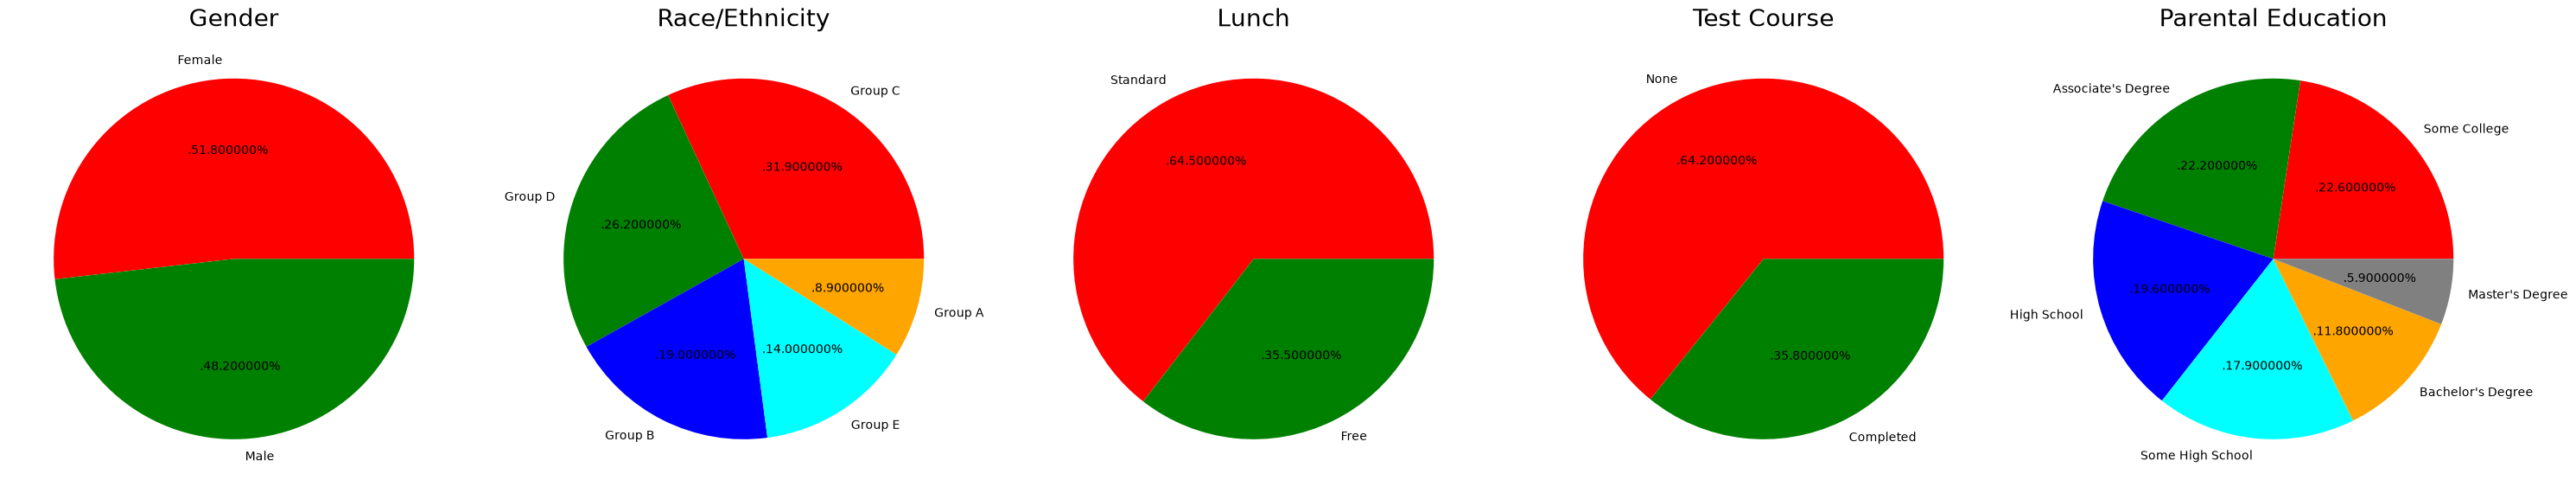

In [54]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race/ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test preparation course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental level of education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

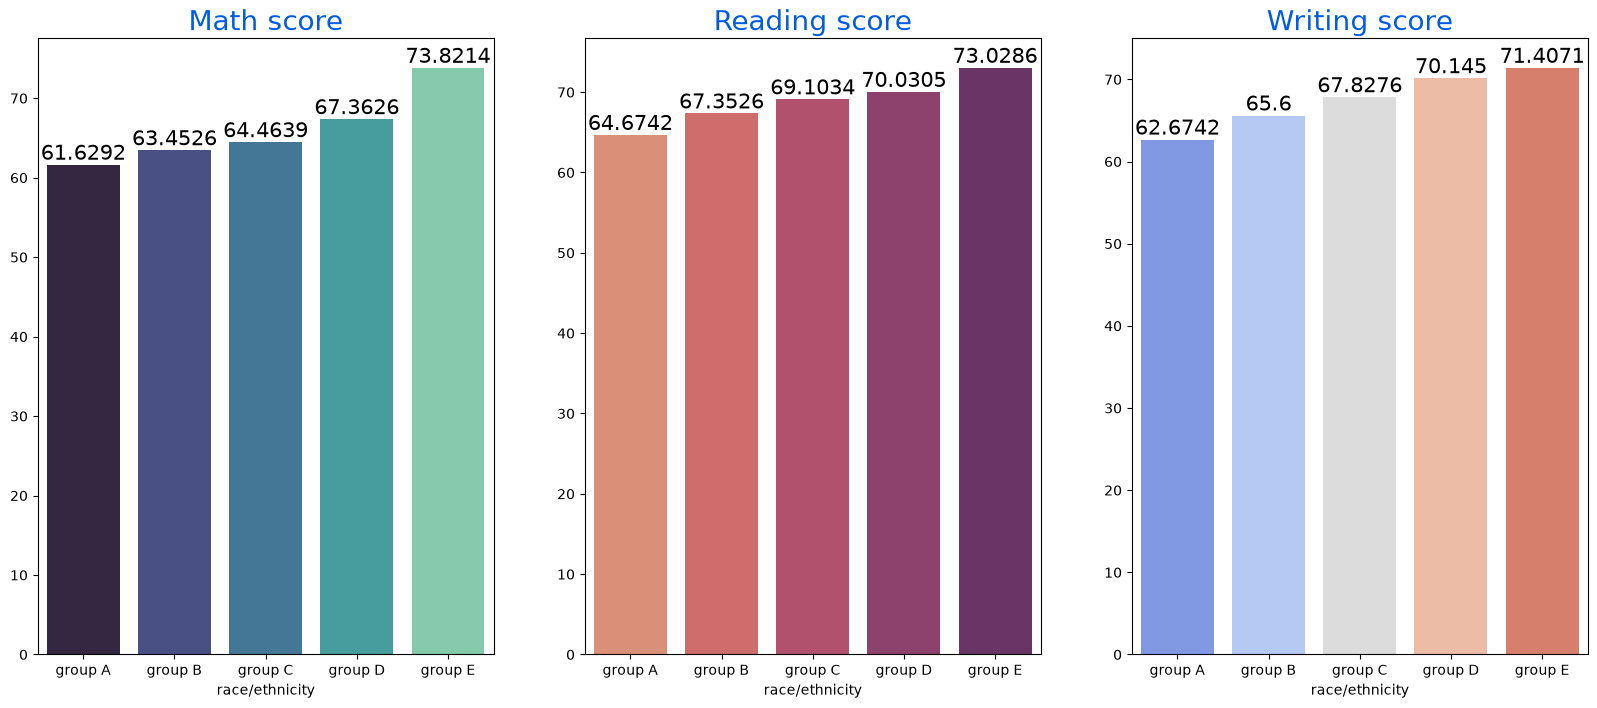

In [56]:
Group_data2=df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math score'].mean().index,y=Group_data2['math score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing score'].mean().index,y=Group_data2['writing score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

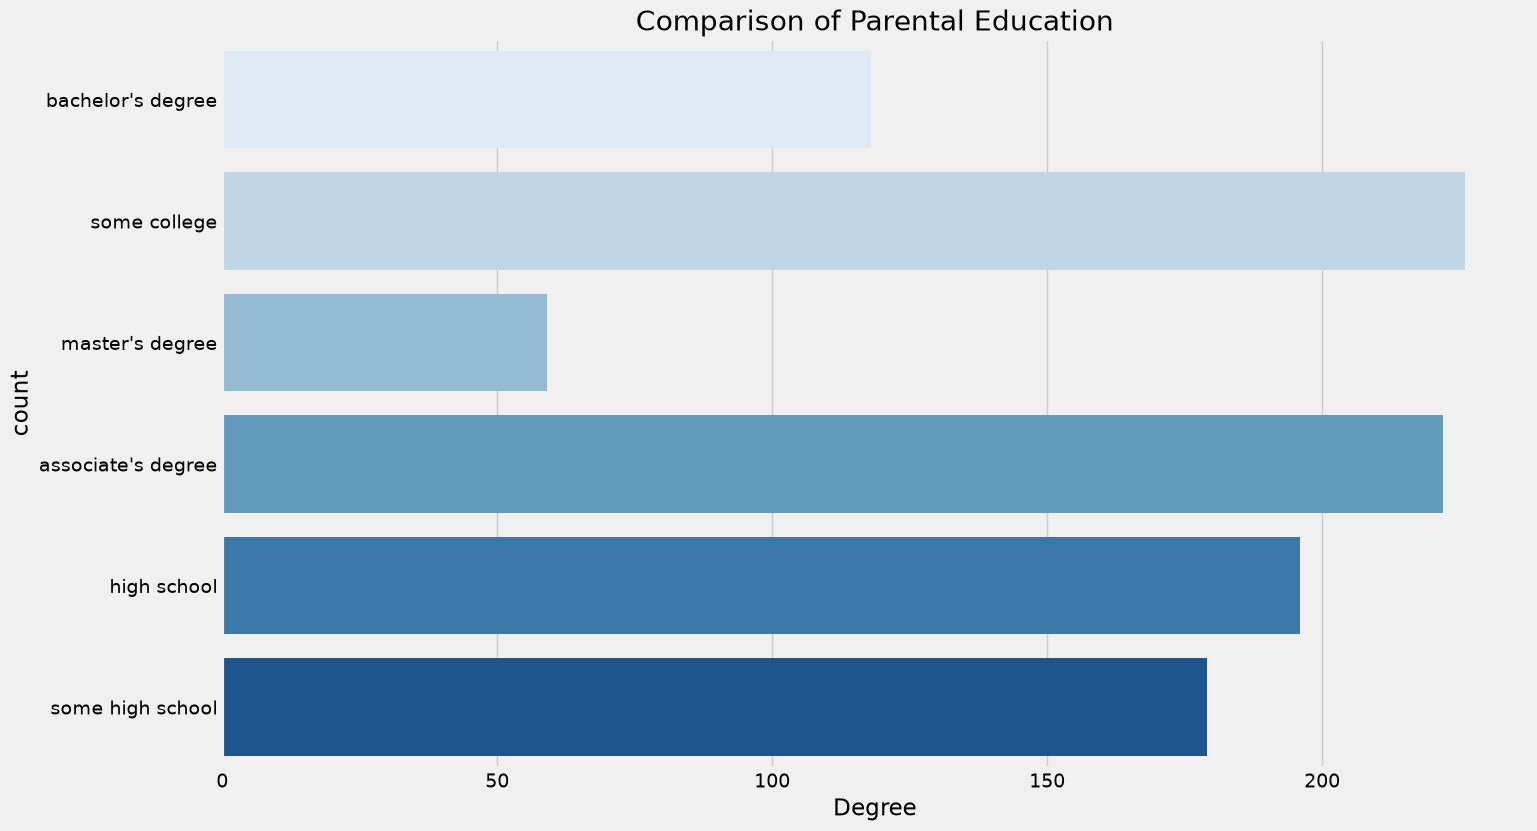

In [58]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental level of education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

In [65]:
import openpyxl

df.to_excel('data/stud_cleaned.xlsx', index=False, engine='openpyxl')
df.to_csv('data/stud_clean.csv', index=False)
